# Proyek Analisis Data: Air Quality Dataset
## Multi-Station Analysis — 12 Stasiun Pemantauan Beijing (2013–2017)

- **Nama:** Vidi Joshubzky Saviola


## Menentukan Pertanyaan Bisnis

1. **Pertanyaan 1:** Bagaimana tren tingkat polusi udara (PM2.5) dari waktu ke waktu dan apakah ada perbedaan tingkat polusi antara stasiun pemantauan di pusat kota vs pinggiran kota?
2. **Pertanyaan 2:** Bagaimana korelasi antara variabel cuaca (Suhu, Curah Hujan, Kecepatan Angin) dengan tingkat polusi udara (PM2.5)? Stasiun mana yang paling terpengaruh oleh faktor cuaca?

## 1. Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import glob
import os

## 2. Data Wrangling
### 2.1 Gathering Data
Memuat seluruh 12 dataset stasiun pemantauan kualitas udara di Beijing.

In [2]:
csv_files = sorted(glob.glob('data/PRSA_Data_*.csv'))
print(f"Found {len(csv_files)} station files")

all_dfs = []
for f in csv_files:
    station_df = pd.read_csv(f)
    all_dfs.append(station_df)
    print(f"  {os.path.basename(f)} -> {len(station_df)} rows, station: {station_df['station'].iloc[0]}")

df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal combined rows: {len(df)}")
print(f"Stations: {df['station'].unique()}")
df.head()

Found 12 station files
  PRSA_Data_Aotizhongxin_20130301-20170228.csv -> 35064 rows, station: Aotizhongxin
  PRSA_Data_Changping_20130301-20170228.csv -> 35064 rows, station: Changping
  PRSA_Data_Dingling_20130301-20170228.csv -> 35064 rows, station: Dingling
  PRSA_Data_Dongsi_20130301-20170228.csv -> 35064 rows, station: Dongsi
  PRSA_Data_Guanyuan_20130301-20170228.csv -> 35064 rows, station: Guanyuan
  PRSA_Data_Gucheng_20130301-20170228.csv -> 35064 rows, station: Gucheng
  PRSA_Data_Huairou_20130301-20170228.csv -> 35064 rows, station: Huairou
  PRSA_Data_Nongzhanguan_20130301-20170228.csv -> 35064 rows, station: Nongzhanguan
  PRSA_Data_Shunyi_20130301-20170228.csv -> 35064 rows, station: Shunyi
  PRSA_Data_Tiantan_20130301-20170228.csv -> 35064 rows, station: Tiantan
  PRSA_Data_Wanliu_20130301-20170228.csv -> 35064 rows, station: Wanliu
  PRSA_Data_Wanshouxigong_20130301-20170228.csv -> 35064 rows, station: Wanshouxigong

Total combined rows: 420768
Stations: ['Aotizhongxin' 

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### 2.2 Assessing Data
Memeriksa tipe data, missing values, dan duplikasi.

In [3]:
print("=== Data Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isna().sum())
print(f"\nTotal missing: {df.isna().sum().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB
None

=== Missing Values ==

### 2.3 Cleaning Data
1. Menangani missing values menggunakan forward fill dan backward fill per stasiun (data time series).
2. Membuat kolom `datetime` dari kolom tahun, bulan, hari, jam.
3. Membuat kolom kategori kualitas udara berdasarkan standar PM2.5 EPA.

In [4]:
# Forward fill per station
df = df.groupby('station', group_keys=False).apply(lambda g: g.ffill())
# Backward fill remaining NaNs at the start
df = df.groupby('station', group_keys=False).apply(lambda g: g.bfill())

# Create datetime column
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

print(f"Missing values after cleaning: {df.isna().sum().sum()}")
df.head()

/var/folders/4d/23md8m7j4y56f4jf0btz6pph0000gn/T/ipykernel_24218/2585936164.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('station', group_keys=False).apply(lambda g: g.ffill())


Missing values after cleaning: 0


/var/folders/4d/23md8m7j4y56f4jf0btz6pph0000gn/T/ipykernel_24218/2585936164.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('station', group_keys=False).apply(lambda g: g.bfill())


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


## 3. Exploratory Data Analysis (EDA)
### 3.1 Statistik Deskriptif

In [5]:
print(df.describe())

                  No           year          month            day  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean    17532.500000    2014.662560       6.522930      15.729637   
min         1.000000    2013.000000       1.000000       1.000000   
25%      8766.750000    2014.000000       4.000000       8.000000   
50%     17532.500000    2015.000000       7.000000      16.000000   
75%     26298.250000    2016.000000      10.000000      23.000000   
max     35064.000000    2017.000000      12.000000      31.000000   
std     10122.116943       1.177198       3.448707       8.800102   

                hour          PM2.5           PM10            SO2  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean       11.500000      80.150342     105.062381      15.933593   
min         0.000000       2.000000       2.000000       0.285600   
25%         5.750000      20.000000      36.000000       3.000000   
50%        11.500000      55.0000

In [6]:
# Rata-rata PM2.5 per stasiun
station_avg = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
print("Average PM2.5 per station:")
print(station_avg)

Average PM2.5 per station:
station
Dongsi           86.310293
Wanshouxigong    85.356562
Nongzhanguan     85.289471
Gucheng          84.345203
Wanliu           83.516054
Aotizhongxin     83.163652
Guanyuan         83.047023
Tiantan          82.255892
Shunyi           80.021067
Changping        71.119444
Huairou          69.949581
Dingling         67.429857
Name: PM2.5, dtype: float64


### 3.2 Analisis Lanjutan: Kategorisasi Kualitas Udara (Manual Grouping/Binning)
Kita mengelompokkan data berdasarkan indeks PM2.5 menggunakan standar US EPA.

In [7]:
def classify_aqi(pm25):
    if pm25 <= 12: return 'Good'
    elif pm25 <= 35.4: return 'Moderate'
    elif pm25 <= 55.4: return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150.4: return 'Unhealthy'
    elif pm25 <= 250.4: return 'Very Unhealthy'
    else: return 'Hazardous'

df['Air_Quality_Category'] = df['PM2.5'].apply(classify_aqi)
print("Air Quality Category distribution (all stations):")
print(df['Air_Quality_Category'].value_counts())

Air Quality Category distribution (all stations):
Air_Quality_Category
Unhealthy                         145361
Moderate                           92716
Good                               64094
Unhealthy for Sensitive Groups     54303
Very Unhealthy                     45126
Hazardous                          19168
Name: count, dtype: int64


### 3.3 Geospatial Analysis — Koordinat Stasiun dan Rata-rata PM2.5

In [8]:
STATION_COORDS = {
    'Aotizhongxin': (39.9822, 116.3972),
    'Changping':    (40.2180, 116.2310),
    'Dingling':     (40.2920, 116.2200),
    'Dongsi':       (39.9290, 116.4170),
    'Guanyuan':     (39.9290, 116.3390),
    'Gucheng':      (39.9140, 116.1840),
    'Huairou':      (40.3280, 116.6280),
    'Nongzhanguan': (39.9370, 116.4610),
    'Shunyi':       (40.1270, 116.6550),
    'Tiantan':      (39.8820, 116.4070),
    'Wanliu':       (39.9870, 116.2870),
    'Wanshouxigong':(39.8780, 116.3520),
}

station_summary = df.groupby('station').agg(
    avg_PM25=('PM2.5', 'mean'),
    max_PM25=('PM2.5', 'max'),
    avg_TEMP=('TEMP', 'mean'),
    avg_WSPM=('WSPM', 'mean'),
).reset_index()
station_summary['lat'] = station_summary['station'].map(lambda s: STATION_COORDS[s][0])
station_summary['lon'] = station_summary['station'].map(lambda s: STATION_COORDS[s][1])
station_summary

,station,avg_PM25,max_PM25,avg_TEMP,avg_WSPM,lat,lon
0,Aotizhongxin,83.163652,898.0,13.581908,1.708470,39.9822,116.3972
1,Changping,71.119444,882.0,13.670841,1.854067,40.2180,116.2310
2,Dingling,67.429857,881.0,13.670841,1.854067,40.2920,116.2200
3,Dongsi,86.310293,737.0,13.668746,1.860712,39.9290,116.4170
4,Guanyuan,83.047023,680.0,13.581908,1.708470,39.9290,116.3390
5,Gucheng,84.345203,770.0,13.855687,1.343409,39.9140,116.1840
6,Huairou,69.949581,762.0,12.429991,1.652655,40.3280,116.6280
7,Nongzhanguan,85.289471,844.0,13.668746,1.860712,39.9370,116.4610
8,Shunyi,80.021067,941.0,13.375589,1.807578,40.1270,116.6550
9,Tiantan,82.255892,821.0,13.668746,1.860712,39.8820,116.4070


In [9]:
# Create folium map
m = folium.Map(location=[39.95, 116.40], zoom_start=10, tiles='OpenStreetMap')

def get_color(pm25):
    if pm25 <= 35: return 'green'
    elif pm25 <= 75: return 'orange'
    elif pm25 <= 150: return 'red'
    else: return 'darkred'

for _, row in station_summary.iterrows():
    color = get_color(row['avg_PM25'])
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(8, row['avg_PM25'] / 5),
        popup=f"<b>{row['station']}</b><br>Avg PM2.5: {row['avg_PM25']:.1f} µg/m³<br>Max PM2.5: {row['max_PM25']:.0f}",
        tooltip=f"{row['station']}: {row['avg_PM25']:.1f}",
        color=color, fill=True, fill_color=color, fill_opacity=0.7,
    ).add_to(m)

m

## 4. Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren PM2.5 dan perbedaan antara stasiun pusat kota vs pinggiran?

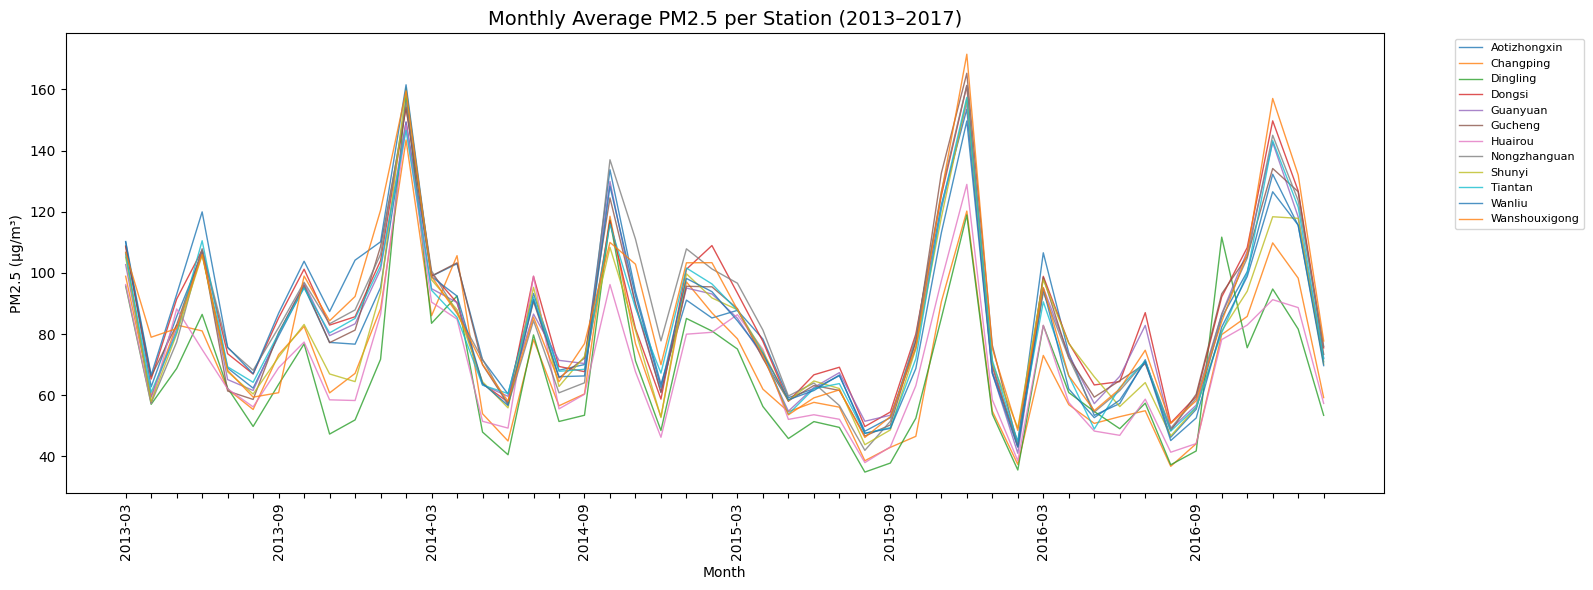

In [10]:
# Monthly average per station
monthly = df.copy()
monthly['year_month'] = monthly['datetime'].dt.to_period('M').astype(str)
monthly_avg = monthly.groupby(['year_month', 'station'])['PM2.5'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
for station in df['station'].unique():
    station_data = monthly_avg[monthly_avg['station'] == station]
    ax.plot(station_data['year_month'], station_data['PM2.5'], label=station, alpha=0.8, linewidth=1)

ax.set_title('Monthly Average PM2.5 per Station (2013–2017)', fontsize=14)
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('Month')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ticks = ax.get_xticklabels()
for i, t in enumerate(ticks):
    if i % 6 != 0: t.set_visible(False)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

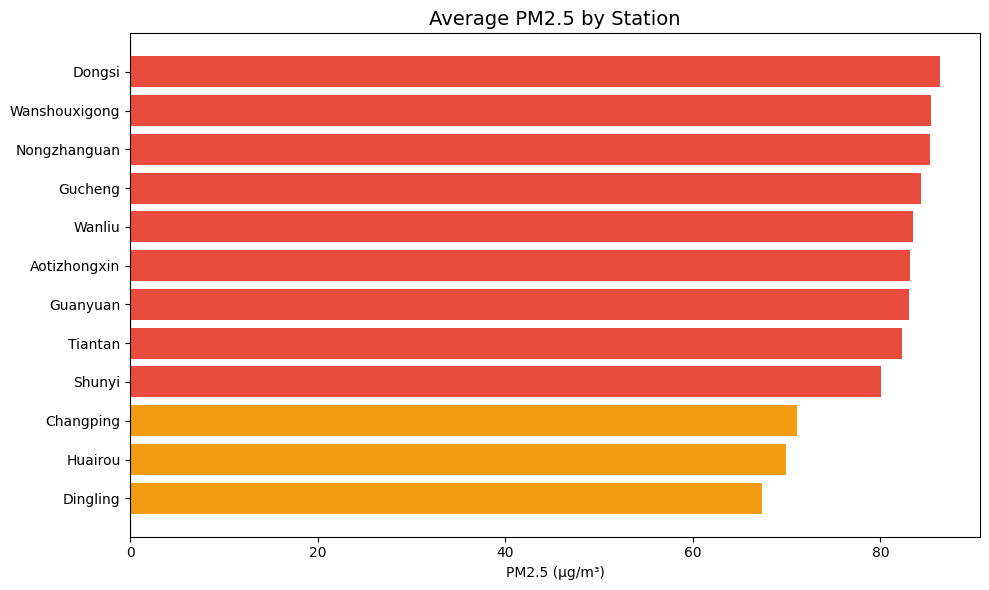

In [11]:
# Average PM2.5 per station — bar chart
station_avg_sorted = df.groupby('station')['PM2.5'].mean().sort_values(ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v <= 50 else '#f39c12' if v <= 75 else '#e74c3c' for v in station_avg_sorted['PM2.5']]
ax.barh(station_avg_sorted['station'], station_avg_sorted['PM2.5'], color=colors)
ax.set_title('Average PM2.5 by Station', fontsize=14)
ax.set_xlabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

### Pertanyaan 2: Korelasi cuaca dengan PM2.5

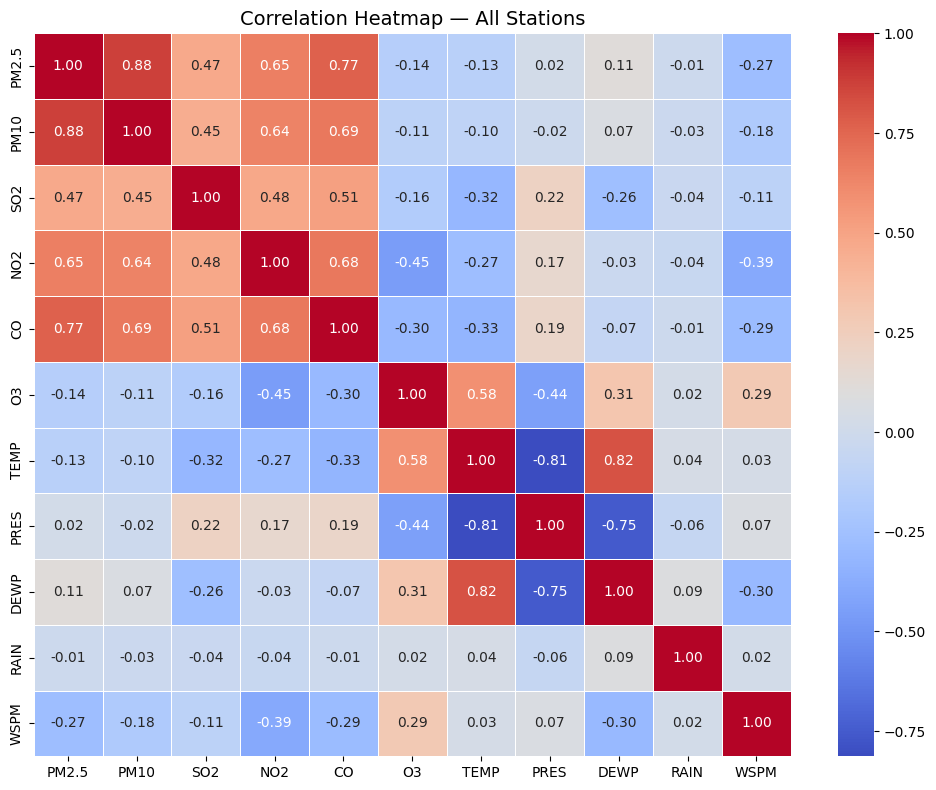

In [12]:
cols_for_corr = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr = df[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — All Stations', fontsize=14)
plt.tight_layout()
plt.show()

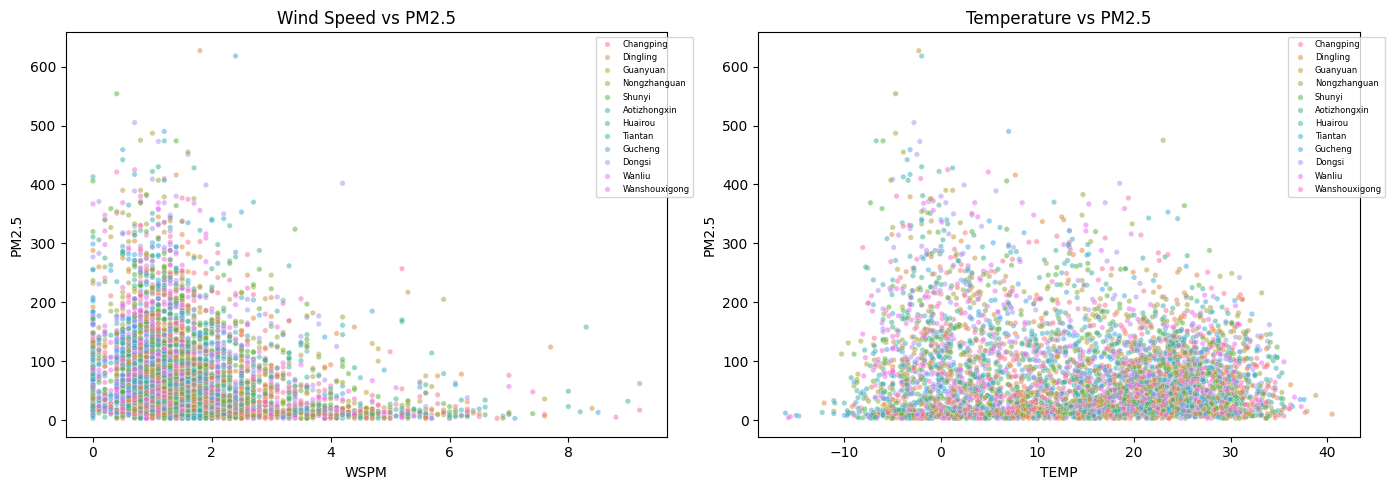

In [13]:
# Scatter: Wind Speed vs PM2.5
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=sample, x='WSPM', y='PM2.5', hue='station', alpha=0.5, ax=axes[0], s=15)
axes[0].set_title('Wind Speed vs PM2.5')
axes[0].legend(fontsize=6, bbox_to_anchor=(1.05, 1))

sns.scatterplot(data=sample, x='TEMP', y='PM2.5', hue='station', alpha=0.5, ax=axes[1], s=15)
axes[1].set_title('Temperature vs PM2.5')
axes[1].legend(fontsize=6, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

## 5. Conclusion

- **Conclution pertanyaan 1:** Tren PM2.5 menunjukkan pola musiman yang kuat di semua stasiun, dengan puncak polusi di musim dingin (November–Februari) dan penurunan di musim panas. Stasiun di pusat kota seperti Dongsi, Wanshouxigong, dan Nongzhanguan cenderung memiliki rata-rata PM2.5 yang lebih tinggi dibandingkan stasiun pinggiran seperti Dingling dan Huairou. Peta geospasial (folium) memperlihatkan dengan jelas bahwa stasiun yang lebih dekat ke pusat perkotaan Beijing memiliki polusi yang lebih tinggi.

- **Conclution pertanyaan 2:** Curah Hujan (RAIN) dan Kecepatan Angin (WSPM) memiliki korelasi negatif dengan PM2.5, menandakan bahwa hujan dan angin kencang membantu mengurangi polusi. Suhu (TEMP) juga memiliki korelasi negatif moderat karena musim panas umumnya memiliki kualitas udara lebih baik. CO, SO2, dan NO2 berkorelasi positif kuat dengan PM2.5, menunjukkan sumber polusi yang saling terkait.

### Export Cleaned Data for Dashboard

In [14]:
os.makedirs('dashboard', exist_ok=True)
df.to_csv('dashboard/all_stations_data.csv', index=False)
station_summary.to_csv('dashboard/station_summary.csv', index=False)
print("Data saved!")

Data saved!
